In [154]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("merged_players.csv", parse_dates=['born_date', 'debut_date', 'last_date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25070 entries, 0 to 25069
Data columns (total 67 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   player_id                    25070 non-null  int64         
 1   player_name                  25070 non-null  str           
 2   player_full_name             25070 non-null  str           
 3   first_name                   25070 non-null  str           
 4   last_name                    25070 non-null  str           
 5   born_date                    25070 non-null  datetime64[us]
 6   debut_date                   25070 non-null  datetime64[us]
 7   debut_age                    25070 non-null  int64         
 8   last_date                    25070 non-null  datetime64[us]
 9   last_age                     25070 non-null  int64         
 10  height                       25070 non-null  int64         
 11  weight                       25070 non-null  float64

C:\Users\MEE\AppData\Local\Temp\ipykernel_8664\1129948439.py:5: DtypeWarning: Columns (0: is_finals) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_players.csv", parse_dates=['born_date', 'debut_date', 'last_date'])


<Axes: title={'center': 'Goals over the year'}, xlabel='year', ylabel='goals'>

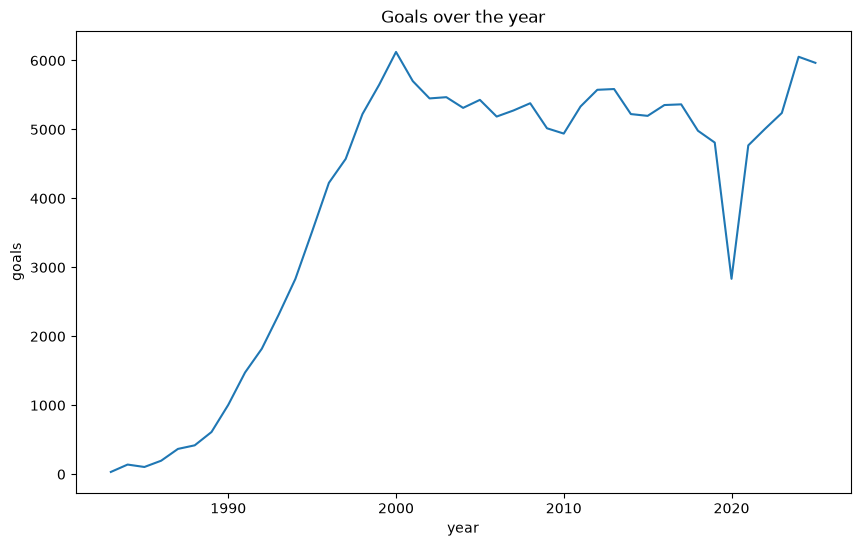

In [155]:
plt.figure(figsize=(10, 6))
plt.title("Goals over the year")
goals_by_years = df.groupby('year', as_index=False)['goals'].sum()
sns.lineplot(data=goals_by_years, x="year", y="goals")

### Line Plot showing, in 2020 numbers of goals scored yearly was reduced drastically, less matches because of covid?

<Axes: title={'center': 'Tackles over 2002 - 2025'}, xlabel='year', ylabel='avg_tackles'>

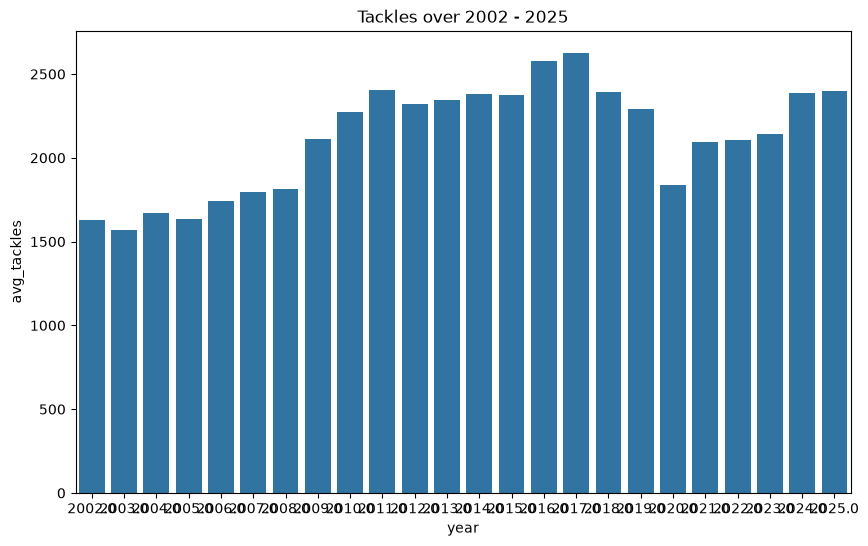

In [156]:
plt.figure(figsize=(10,6))
plt.title("Tackles over 2002 - 2025")
tackles_df = df[(df['year'] >= 2002) & (df['year'] <= 2025)]
tackle_over_year = tackles_df.groupby('year', as_index=False)['avg_tackles'].sum()
sns.barplot(tackle_over_year, x='year' ,y='avg_tackles')


### Bar plot players tackles from year 2002 - 2025 shows that tackles gradually increased over the year but with one irregularity of 2020 where it hit a downfall, rule change or just because less matches were played?


<Axes: title={'center': 'Average Kicks Distribution'}, xlabel='avg_kicks', ylabel='Count'>

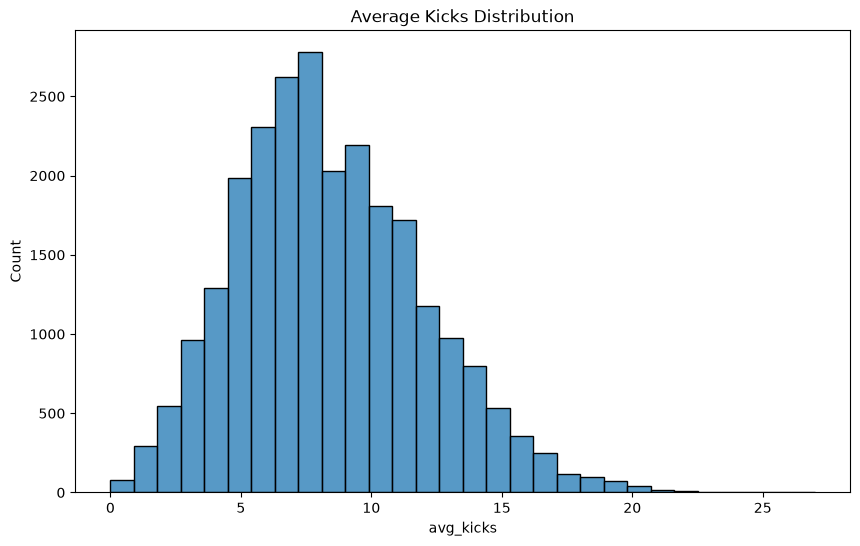

In [157]:
plt.figure(figsize=(10, 6))
plt.title("Average Kicks Distribution")
sns.histplot(df['avg_kicks'], bins=30)


### Average Kicks distribution by players during matches

<Axes: title={'center': 'GOALS Scored over disposals in 2025'}, xlabel='avg_disposals', ylabel='avg_score'>

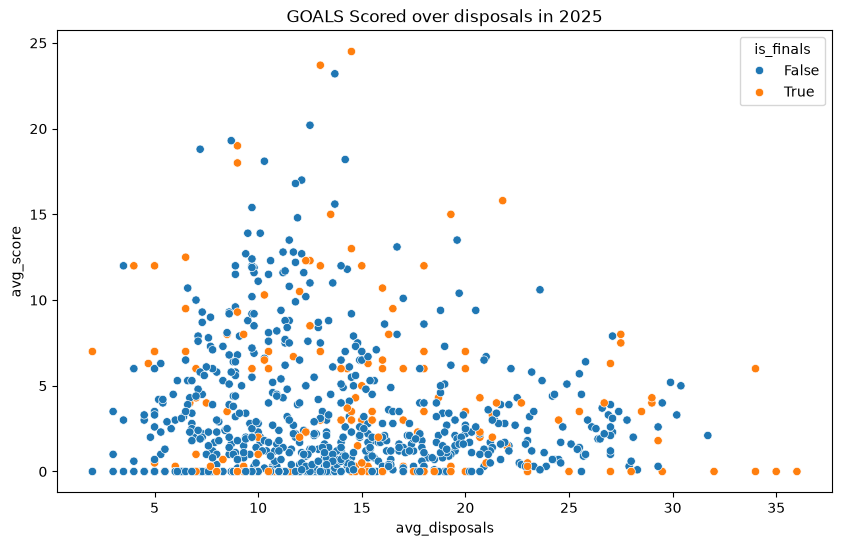

In [158]:
plt.figure(figsize=(10,6))
plt.title("GOALS Scored over disposals in 2025")
year_20_25 = df[(df['year'] == 2025)]
sns.scatterplot(x=year_20_25['avg_disposals'], y=year_20_25['avg_score'], hue=year_20_25['is_finals'])

### Scatter plot of average goals scored over disposals and in finals of year 2025 suggests that average score increases as there are less disposals, the more the possession the more chance of scoring

Text(0.5, 1.0, 'Average Fantasy distribution for finals vs non-finals')

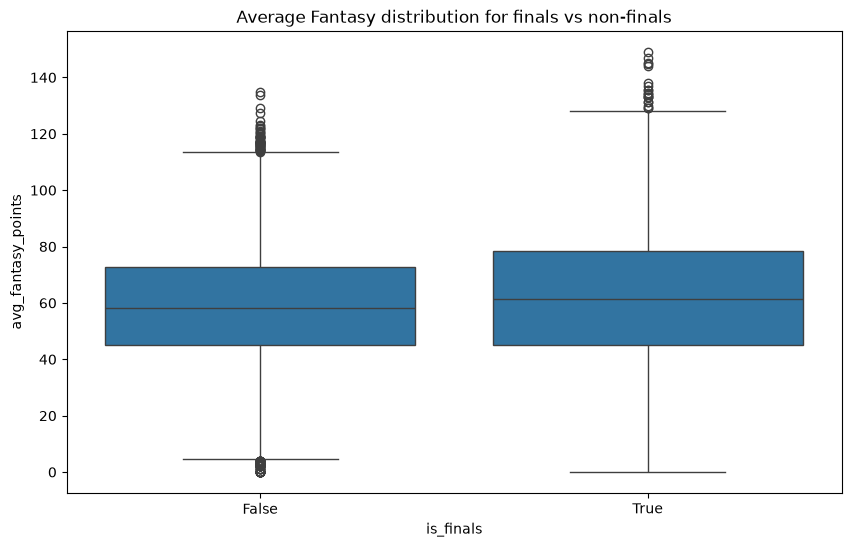

In [159]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_finals', y='avg_fantasy_points')
plt.title('Average Fantasy distribution for finals vs non-finals')

### Box plot comparing fantasy points in finals vs non-finals shows finals or not fantasy points remain same.

Text(0.5, 1.0, 'Correlation heatmap of selected average metrics')

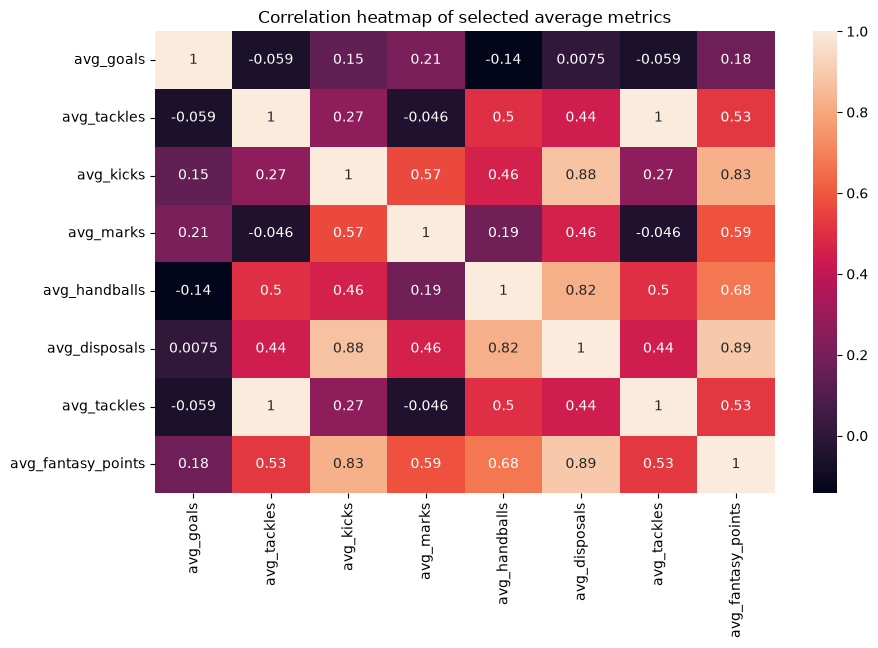

In [160]:
plt.figure(figsize=(10, 6))
corr_cols = ['avg_goals', 'avg_tackles', 'avg_kicks', 'avg_marks', 'avg_handballs', 'avg_disposals', 'avg_tackles', 'avg_fantasy_points']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation heatmap of selected average metrics')

### Heatmap of correlations between selected average performance metrics

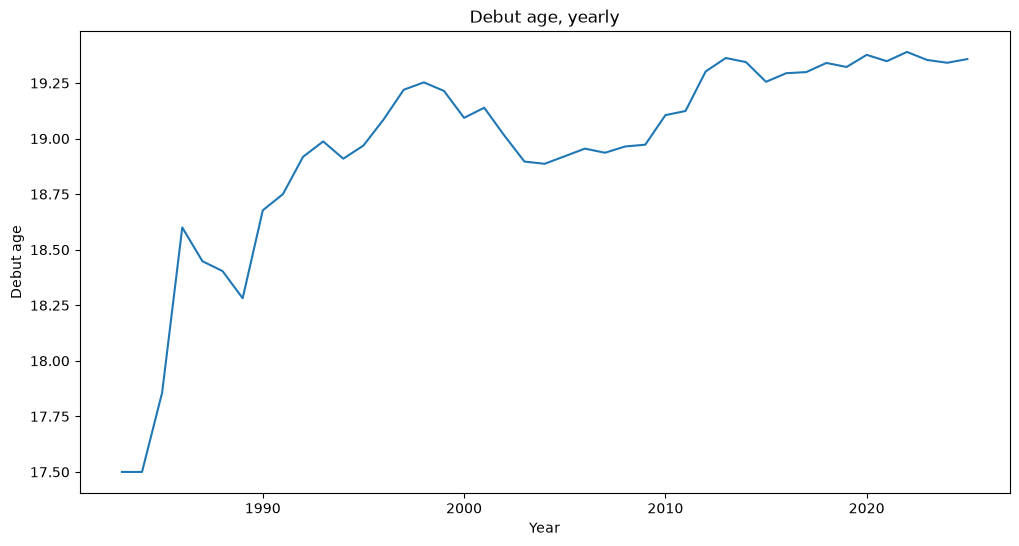

In [161]:
debut_age = df.dropna(subset=['year', 'debut_age'])
debut_age = debut_age.groupby('year', as_index=False)['debut_age'].agg(['mean']).reset_index()
plt.figure(figsize=(12,6))
plt.title("Debut age, yearly")
sns.lineplot(data=debut_age, x='year', y='mean')
plt.xlabel("Year")
plt.ylabel("Debut age")
plt.show()

### Line chart shows that the average age when player debut increased over the years, more competition or a rule set to atleast 18 years old can debut?